# Quantum dots: a realistic Hamiltonian

Executable companion to chapter 11.

Every system so far has been a model with one or two parameters.  This one is
not: $N$ electrons confined to two dimensions by a parabolic trap and
interacting through the bare Coulomb repulsion,

$$
\hat H = \sum_{i=1}^{N}\left(-\tfrac12\nabla_i^2 + \tfrac12\omega^2 r_i^2\right)
       + \sum_{i<j}\frac{1}{|\bm r_i - \bm r_j|},
$$

in natural units $\hbar = m_e = e = 1$.  Every matrix element has to be
computed, the single-particle basis is infinite and has to be truncated, and
the truncation error has to be controlled alongside the many-body error.

The single-particle basis is the two-dimensional oscillator in polar
coordinates, with energies $\varepsilon_{nm}=\hbar\omega(2n+|m|+1)$, so shells
$N_s = 2n+|m|$ have degeneracy $2(N_s+1)$ and the closed shells fall at
$N = 2, 6, 12, 20, 30, 42$ — the magic numbers.

Everything after the construction of the one- and two-body matrices is
imported from `coupledcluster.py`: the same Hartree-Fock, MP2, CCD, CCSD and
unitary coupled-cluster routines that were validated on the pairing model of
chapter 10, applied here unchanged.

In [1]:
import sys
sys.path.insert(0, "../BookManybody/BookMaterial/Programs")

import math
import numpy as np
import matplotlib.pyplot as plt

import quantumdot as qd
from coupledcluster import (ccd, ccsd, hartree_fock, mp2_energy,
                            reference_energy, UnitaryCC)

## 1. The basis and the magic numbers

In [2]:
dot = qd.QuantumDot(2, shells=5)
print(f"shells 0-5: {len(dot.spatial)} spatial states, "
      f"{dot.n_orbitals} spin-orbitals\n")
print(f"{'N_s':>4s}  {'(n, m)':<44s} {'deg.':>5s} {'cumulative N':>13s}")
total = 0
for n_s in range(6):
    states = [s for k, s in enumerate(dot.spatial) if dot.shell_of(k) == n_s]
    total += 2*len(states)
    label = " ".join(f"({n},{m:+d})" if m else f"({n}, 0)" for n, m in states)
    print(f"{n_s:4d}  {label:<44s} {2*len(states):5d} {total:13d}")

shells 0-5: 21 spatial states, 42 spin-orbitals

 N_s  (n, m)                                        deg.  cumulative N
   0  (0, 0)                                           2             2
   1  (0,-1) (0,+1)                                    4             6
   2  (0,-2) (1, 0) (0,+2)                             6            12
   3  (0,-3) (1,-1) (1,+1) (0,+3)                      8            20
   4  (0,-4) (1,-2) (2, 0) (1,+2) (0,+4)              10            30
   5  (0,-5) (1,-3) (2,-1) (2,+1) (1,+3) (0,+5)       12            42


## 2. The Coulomb matrix element

Two exact statements do more for us than the closed form itself.  Angular
momentum is conserved, $m_p+m_q = m_r+m_s$, which kills most of the index
combinations before any work is done; and the whole frequency dependence is a
factor $\sqrt{\hbar\omega}$, so the expensive integrals are computed once.

The lowest element is known analytically:
$\langle 00;00|v|00;00\rangle = \sqrt{\pi/2}\,\sqrt{\hbar\omega}$.

In [3]:
element = qd.coulomb_ho(1.0, 0, 0, 0, 0, 0, 0, 0, 0)
print(f"<00;00|v|00;00> = {element:.12f}")
print(f"sqrt(pi/2)      = {math.sqrt(math.pi/2):.12f}")
print(f"agree: {abs(element - math.sqrt(math.pi/2)) < 1e-12}\n")

print("the hw dependence is a pure scale factor:")
for hw in (0.25, 0.5, 1.0, 2.0, 4.0):
    value = qd.coulomb_ho(hw, 0, 0, 0, 0, 0, 0, 0, 0)
    print(f"   hw = {hw:5.2f}: {value:12.8f}   "
          f"value/sqrt(hw) = {value/math.sqrt(hw):.12f}")

print("\nangular-momentum conservation:")
for label, args in (("<0,+1;0,-1|v|0,0;0,0>  (allowed)", (0,1,0,-1,0,0,0,0)),
                    ("<0,+1;0, 0|v|0,0;0,0>  (forbidden)", (0,1,0,0,0,0,0,0)),
                    ("<0,+2;0,-1|v|0,+1;0,0> (allowed)", (0,2,0,-1,0,1,0,0)),
                    ("<0,+2;0, 0|v|0,+1;0,0> (forbidden)", (0,2,0,0,0,1,0,0))):
    print(f"   {label:38s} = {qd.coulomb_ho(1.0, *args):+.8f}")

<00;00|v|00;00> = 1.253314137316
sqrt(pi/2)      = 1.253314137316
agree: True

the hw dependence is a pure scale factor:
   hw =  0.25:   0.62665707   value/sqrt(hw) = 1.253314137316
   hw =  0.50:   0.88622693   value/sqrt(hw) = 1.253314137316
   hw =  1.00:   1.25331414   value/sqrt(hw) = 1.253314137316
   hw =  2.00:   1.77245385   value/sqrt(hw) = 1.253314137316
   hw =  4.00:   2.50662827   value/sqrt(hw) = 1.253314137316

angular-momentum conservation:
   <0,+1;0,-1|v|0,0;0,0>  (allowed)       = +0.31332853
   <0,+1;0, 0|v|0,0;0,0>  (forbidden)     = +0.00000000
   <0,+2;0,-1|v|0,+1;0,0> (allowed)       = +0.27694591
   <0,+2;0, 0|v|0,+1;0,0> (forbidden)     = +0.00000000


## 3. Hartree-Fock and the size of the basis

Adding a shell can only lower the energy: the Hartree-Fock state gains
variational freedom and nothing is taken away.  Note that some shells change
nothing at all for $N=2$ — the occupied orbital has $m=0$ and can only mix
with other $m=0$ states, which live in the even shells.

In [4]:
print(f"{'shells':>7s} {'orbitals':>9s} {'N=2 E_HF':>14s} {'dE':>11s} "
      f"{'N=6 E_HF':>14s} {'dE':>11s}")
previous = {2: None, 6: None}
for shells in range(0, 6):
    n_orb = 2*len(qd.spatial_basis(shells))
    row = [f"{shells:7d}", f"{n_orb:9d}"]
    for particles in (2, 6):
        if n_orb < particles:
            row += [f"{'--':>14s}", f"{'--':>11s}"]
            continue
        e = qd.solve(particles, shells, methods=())["E_HF"]
        row.append(f"{e:14.8f}")
        row.append(f"{'--':>11s}" if previous[particles] is None
                   else f"{e-previous[particles]:+11.6f}")
        previous[particles] = e
    print(" ".join(row))

 shells  orbitals       N=2 E_HF          dE       N=6 E_HF          dE
      0         2     3.25331414          --             --          --
      1         6     3.25331414   +0.000000    22.21981284          --
      2        12     3.16269135   -0.090623    21.59319848   -0.626614
      3        20     3.16269135   +0.000000    20.76691943   -0.826279


      4        30     3.16192140   -0.000770    20.74840225   -0.018517


      5        42     3.16192140   +0.000000    20.72025707   -0.028145


## 4. The hierarchy of methods

Hartree-Fock, MP2, CCD and CCSD in the full 42-orbital basis at
$\hbar\omega=1$.

In [5]:
results = {n: qd.solve(n, 5) for n in (2, 6)}

print(f"{'quantity':<32s} {'N = 2':>15s} {'N = 6':>15s}")
print("-"*64)
rows = [("non-interacting  E_0", lambda r: r["E0"]),
        ("Hartree-Fock  E_HF", lambda r: r["E_HF"]),
        ("  interaction  E_HF - E_0", lambda r: r["E_HF"]-r["E0"]),
        ("MP2 correlation", lambda r: r["E_MP2"]),
        ("  total", lambda r: r["E_HF"]+r["E_MP2"]),
        ("CCD correlation", lambda r: r["E_CCD"]),
        ("  total", lambda r: r["E_HF"]+r["E_CCD"]),
        ("CCSD correlation", lambda r: r["E_CCSD"]),
        ("  total", lambda r: r["E_HF"]+r["E_CCSD"])]
for label, f in rows:
    print(f"{label:<32s} {f(results[2]):15.8f} {f(results[6]):15.8f}")

print()
for n in (2, 6):
    r = results[n]
    print(f"N = {n}: SCF {r['iterations']} iterations, CCD "
          f"{r['CCD_iterations']}, CCSD {r['CCSD_iterations']}, "
          f"max|t_1| = {r['t1_max']:.2e}")

quantity                                   N = 2           N = 6
----------------------------------------------------------------
non-interacting  E_0                  2.00000000     10.00000000
Hartree-Fock  E_HF                    3.16192140     20.72025707
  interaction  E_HF - E_0             1.16192140     10.72025707
MP2 correlation                      -0.13488329     -0.41769581
  total                               3.02703812     20.30256126
CCD correlation                      -0.14799908     -0.44624450
  total                               3.01392232     20.27401257
CCSD correlation                     -0.14829527     -0.44701044
  total                               3.01362613     20.27324663

N = 2: SCF 15 iterations, CCD 23, CCSD 23, max|t_1| = 5.70e-03
N = 6: SCF 24 iterations, CCD 19, CCSD 28, max|t_1| = 1.01e-02


### The singles amplitudes do not vanish

It is often said that Brillouin's theorem makes $T_1 = 0$ for a closed-shell
Hartree-Fock reference, so that CCSD reduces to CCD.  That is wrong.
Brillouin's theorem gives $f_{ai}=0$, which is why MP2 has no singles
contribution — but the CCSD singles equation contains

$$
\tfrac12\sum_{mef}t_{im}^{ef}\langle ma\|ef\rangle
\qquad\text{and}\qquad
-\tfrac12\sum_{men}t_{mn}^{ae}\langle nm\|ei\rangle,
$$

which are built from the **doubles** and survive at $t_1=0$.  The singles are
driven by the doubles, they are small but non-zero (about $10^{-2}$ above),
and they describe orbital relaxation.  A code that reports $t_1 = 0$
identically has a bug in its singles equation.

## 5. Two electrons against the exact answer

With $N=2$ the determinant space is small enough to diagonalise, and singles
and doubles *exhaust* the excitations available to two particles — so CCSD
must be exact within the basis.  Checking that is a far stronger test of the
coupled-cluster solver than anything the pairing model could provide.

The basis series converges to Taut's analytic result $E = 3$ at
$\hbar\omega = 1$, but slowly: the oscillator basis cannot reproduce the
Coulomb cusp.

In [6]:
print(f"{'shells':>6s} {'orb':>4s} {'dim':>5s} {'E_HF':>13s} "
      f"{'+MP2':>13s} {'+CCD':>13s} {'+CCSD':>13s} {'E_FCI':>13s} "
      f"{'|CCSD-FCI|':>11s}")
shells_list, errors = [], []
for shells in (1, 2, 3, 4, 5):
    r = qd.solve(2, shells)
    exact, n_orb, dim = qd.exact_two_electron(shells)
    total = r["E_HF"] + r["E_CCSD"]
    shells_list.append(n_orb)
    errors.append(exact - 3.0)
    print(f"{shells:6d} {n_orb:4d} {dim:5d} {r['E_HF']:13.8f} "
          f"{r['E_HF']+r['E_MP2']:13.8f} {r['E_HF']+r['E_CCD']:13.8f} "
          f"{total:13.8f} {exact:13.8f} {abs(total-exact):11.1e}")
print(f"{'exact':>6s} {'inf':>4s} {'--':>5s} {'--':>13s} {'--':>13s} "
      f"{'--':>13s} {'--':>13s} {3.0:13.8f}")

shells  orb   dim          E_HF          +MP2          +CCD         +CCSD         E_FCI  |CCSD-FCI|
     1    6    15    3.25331414    3.17856150    3.15232801    3.15232801    3.15232801     2.0e-13
     2   12    66    3.16269135    3.05797643    3.03904782    3.03860458    3.03860458     2.3e-13
     3   20   190    3.16269135    3.04440370    3.02527309    3.02523058    3.02523058     2.1e-13


     4   30   435    3.16192140    3.03341846    3.01794371    3.01760623    3.01760623     3.3e-13


     5   42   861    3.16192140    3.02703812    3.01392232    3.01362613    3.01362613     3.5e-13
 exact  inf    --            --            --            --            --    3.00000000


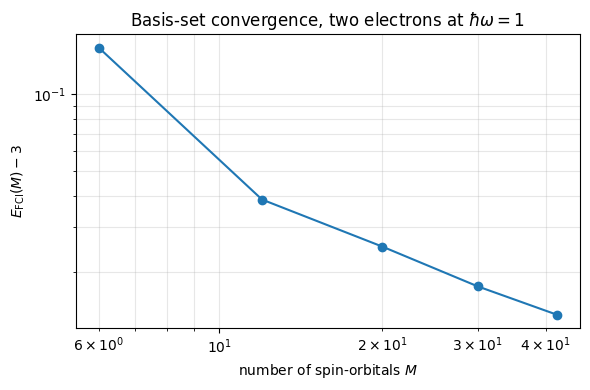

In [7]:
plt.figure(figsize=(6, 4))
plt.loglog(shells_list, errors, "o-")
plt.xlabel("number of spin-orbitals $M$")
plt.ylabel(r"$E_{\rm FCI}(M) - 3$")
plt.title("Basis-set convergence, two electrons at $\\hbar\\omega=1$")
plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## 6. Six electrons against exact diagonalisation

At 42 orbitals the six-electron space has $\binom{42}{6} = 5\,245\,786$
determinants and is out of reach.  In the two-shell basis it is only
$\binom{12}{6} = 924$, and there the truncation of the cluster operator
genuinely matters — so this is the one place where every method can be
compared with the exact answer on a realistic interaction in a non-trivial
system.

The unitary result is evaluated at the *converged CCSD amplitudes*, not at its
own variational optimum, and is still the best of the four.

In [8]:
h, v = qd.matrices(2)
h_hf, v_hf, _, _ = hartree_fock(h, v, 6)
f_hf = h_hf + np.einsum("piqi->pq", v_hf[:, :6, :, :6])
e_ref = reference_energy(h_hf, v_hf, 6)
cc_d, cc_sd = ccd(f_hf, v_hf, 6), ccsd(f_hf, v_hf, 6)

ucc = UnitaryCC(h_hf, v_hf, 6, singles=True, doubles=True)
exact = float(np.linalg.eigvalsh(ucc.H)[0])
x = qd.ucc_amplitudes_from_ccsd(ucc, cc_sd["t1"], cc_sd["t2"], 6)
e_ucc = ucc.energy(x)

corr = exact - e_ref
print(f"12 orbitals, determinant space {ucc.dim}, "
      f"{ucc.n_amplitudes} amplitudes,  E_corr = {corr:.8f}\n")
print(f"{'method':<28s} {'energy':>14s} {'error':>11s} {'% of E_corr':>12s}")
for label, energy in (("Hartree-Fock", e_ref),
                      ("MP2", e_ref + mp2_energy(f_hf, v_hf, 6)),
                      ("CCD", e_ref + cc_d["energy"]),
                      ("CCSD", e_ref + cc_sd["energy"]),
                      ("UCCSD (CCSD amplitudes)", e_ucc),
                      ("exact diagonalisation", exact)):
    print(f"{label:<28s} {energy:14.8f} {energy-exact:11.2e} "
          f"{100*(energy-e_ref)/corr:11.2f}%")

12 orbitals, determinant space 924, 261 amplitudes,  E_corr = -0.17261018

method                               energy       error  % of E_corr
Hartree-Fock                    21.59319848    1.73e-01       -0.00%
MP2                             21.43344056    1.29e-02       92.55%
CCD                             21.42380972    3.22e-03       98.13%
CCSD                            21.42323158    2.64e-03       98.47%
UCCSD (CCSD amplitudes)         21.42196510    1.38e-03       99.20%
exact diagonalisation           21.42058830    0.00e+00      100.00%


## 7. Dependence on the confinement

Kinetic energy scales as $\omega$ and the Coulomb energy as $\sqrt{\omega}$,
so a shallow trap is strongly correlated and a steep one is nearly free.  This
is the same story the pairing model told through $g$, now told by a parameter
an experimentalist can tune.

N = 2, shells 0-3
     hw      E_0          E_HF        E_MP2       E_CCSD    ratio


   0.25    0.500    1.04636728  -0.09401297  -0.11011613  -0.2015
   0.50    1.000    1.79985638  -0.10709593  -0.12598399  -0.1575


   1.00    2.000    3.16269135  -0.11828765  -0.13746077  -0.1182
   2.00    4.000    5.67904776  -0.12736072  -0.14477375  -0.0862


   4.00    8.000   10.41147018  -0.13444879  -0.14905150  -0.0618

N = 6, shells 0-3
     hw      E_0          E_HF        E_MP2       E_CCSD    ratio


   0.25    2.500    7.51489887  -0.22684445  -0.25462828  -0.0508


   0.50    5.000   12.35747075  -0.27386552  -0.30131589  -0.0410


   1.00   10.000   20.76691943  -0.31344013  -0.33871391  -0.0315


   2.00   20.000   35.68955517  -0.34069602  -0.36204083  -0.0231


   4.00   40.000   62.74380826  -0.35483723  -0.37145821  -0.0163



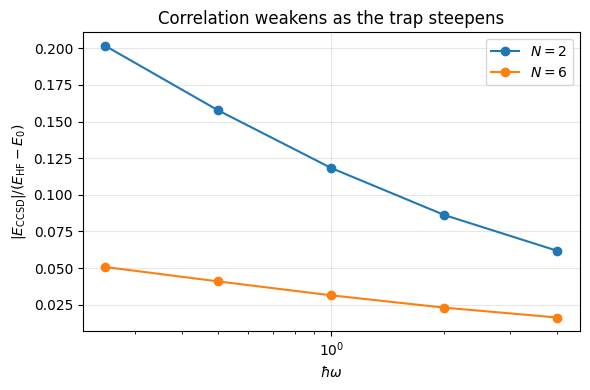

In [9]:
frequencies = (0.25, 0.5, 1.0, 2.0, 4.0)
ratios = {}
for particles in (2, 6):
    print(f"N = {particles}, shells 0-3")
    print(f"{'hw':>7s} {'E_0':>8s} {'E_HF':>13s} {'E_MP2':>12s} "
          f"{'E_CCSD':>12s} {'ratio':>8s}")
    ratios[particles] = []
    for hw in frequencies:
        r = qd.solve(particles, 3, hw=hw)
        ratio = r["E_CCSD"]/(r["E_HF"]-r["E0"])
        ratios[particles].append(ratio)
        print(f"{hw:7.2f} {r['E0']:8.3f} {r['E_HF']:13.8f} "
              f"{r['E_MP2']:12.8f} {r['E_CCSD']:12.8f} {ratio:8.4f}")
    print()

plt.figure(figsize=(6, 4))
for particles in (2, 6):
    plt.plot(frequencies, [-x for x in ratios[particles]], "o-",
             label=f"$N={particles}$")
plt.xscale("log")
plt.xlabel(r"$\hbar\omega$")
plt.ylabel(r"$|E_{\rm CCSD}| / (E_{\rm HF}-E_0)$")
plt.title("Correlation weakens as the trap steepens")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Unitary coupled cluster for two electrons

For two particles everything collapses: UCCSD, CCSD and full diagonalisation
coincide because singles and doubles span the whole space.  Less obviously,
UCCD coincides with CCD — with two particles $T_2T_2$ annihilates the
reference and so does $T_2^\dagger$, so $e^{T_2-T_2^\dagger}|\Phi_0\rangle$
and $(1+T_2)|\Phi_0\rangle$ sweep out the same manifold.

The unitary and the standard ansatz differ only when the truncation genuinely
bites — which is what section 6 showed for six electrons.

In [10]:
print(f"{'shells':>6s} {'orb':>4s} {'ampl':>5s} {'CCD':>13s} {'UCCD':>13s} "
      f"{'CCSD':>13s} {'UCCSD':>13s} {'FCI':>13s}")
for shells in (1, 2):
    h, v = qd.matrices(shells)
    h_hf, v_hf, _, _ = hartree_fock(h, v, 2)
    f_hf = h_hf + np.einsum("piqi->pq", v_hf[:, :2, :, :2])
    e_ref = reference_energy(h_hf, v_hf, 2)
    ucc_d = UnitaryCC(h_hf, v_hf, 2, singles=False, doubles=True)
    ucc_sd = UnitaryCC(h_hf, v_hf, 2, singles=True, doubles=True)
    print(f"{shells:6d} {h.shape[0]:4d} {ucc_sd.n_amplitudes:5d} "
          f"{e_ref+ccd(f_hf, v_hf, 2)['energy']:13.8f} "
          f"{ucc_d.optimise()['energy']:13.8f} "
          f"{e_ref+ccsd(f_hf, v_hf, 2)['energy']:13.8f} "
          f"{ucc_sd.optimise()['energy']:13.8f} "
          f"{qd.two_electron_fci(h, v)[0]:13.8f}")

shells  orb  ampl           CCD          UCCD          CCSD         UCCSD           FCI
     1    6    14    3.15232801    3.15232801    3.15232801    3.15232801    3.15232801


     2   12    65    3.03904782    3.03904782    3.03860458    3.03860458    3.03860458


## 9. Trotterising the unitary ansatz

A quantum computer cannot apply $e^{\hat\sigma}$ in one step; it applies the
generators one at a time, and the splitting error is the Trotter error of
section 6.9.  The number of steps $n$ is the circuit depth.

exact exponential = 3.03864227

 steps         energy        error    ratio
     1     3.03863183     1.04e-05       --
     2     3.03863789     4.38e-06     2.38
     4     3.03864044     1.83e-06     2.40
     8     3.03864146     8.10e-07     2.26
    16     3.03864189     3.77e-07     2.15


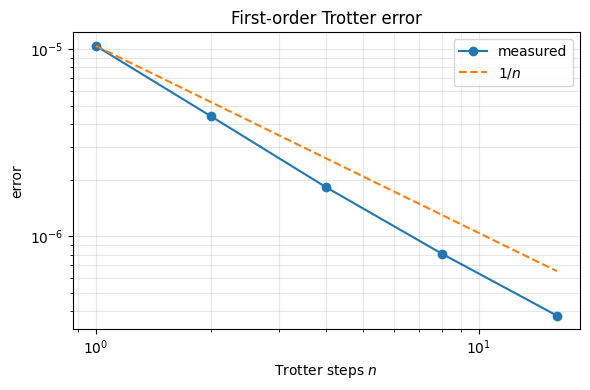

In [11]:
h, v = qd.matrices(2)
h_hf, v_hf, _, _ = hartree_fock(h, v, 2)
f_hf = h_hf + np.einsum("piqi->pq", v_hf[:, :2, :, :2])
cc = ccsd(f_hf, v_hf, 2)
ucc = UnitaryCC(h_hf, v_hf, 2, singles=True, doubles=True)
x = qd.ucc_amplitudes_from_ccsd(ucc, cc["t1"], cc["t2"], 2)
exact_exponential = ucc.energy(x)

print(f"exact exponential = {exact_exponential:.8f}\n")
print(f"{'steps':>6s} {'energy':>14s} {'error':>12s} {'ratio':>8s}")
steps, errs, previous = [], [], None
for n in (1, 2, 4, 8, 16):
    energy = ucc.energy(x, n_trotter=n)
    error = abs(energy - exact_exponential)
    steps.append(n)
    errs.append(error)
    ratio = "--" if previous is None else f"{previous/error:.2f}"
    print(f"{n:6d} {energy:14.8f} {error:12.2e} {ratio:>8s}")
    previous = error

plt.figure(figsize=(6, 4))
plt.loglog(steps, errs, "o-", label="measured")
plt.loglog(steps, [errs[0]/n for n in steps], "--", label=r"$1/n$")
plt.xlabel("Trotter steps $n$")
plt.ylabel("error")
plt.title("First-order Trotter error")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## What the realistic system taught us

The methods survived the move from a one-parameter model to a real interaction
without modification — the same routines, handed a different pair of matrices.
Three things did change:

- **The basis is now an approximation.**  For two electrons the truncation
  error at 42 orbitals is 0.0136, comparable with the entire difference
  between MP2 and CCSD.  Reporting one without the other is meaningless.
- **The hierarchy is quantitative.**  MP2 recovers 92.6% of the correlation
  energy, CCD 98.1%, CCSD 98.5%, the unitary ansatz 99.2%.  The steps get
  smaller and the costs get larger.
- **Folklore does not survive contact with a computation.**  The singles
  amplitudes do not vanish, CCSD is not CCD, and the cheap test that catches
  the error is the two-electron one above.

This Hamiltonian returns in the stochastic chapters, where variational and
diffusion Monte Carlo sample the wave function directly and have no basis-set
error at all — their error is statistical, and of a completely different
nature.  The numbers computed here are the reference they will be measured
against.